<a href="https://colab.research.google.com/github/muhfakhrudin/IntroDPI_IF6A_0043/blob/main/Pengelolaan_Citra_Fakhrudin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import cv2
import numpy as plt
import matplotlib.pyplot as plt

Tipe data: <class 'numpy.ndarray'>
Shape    : (500, 650, 3)
Dtype    : uint8

Artinya:
 Tinggi   = 500 piksel
 Lebar    = 650 piksel
 Channel  = 3 (BGR)
Total piksel:  325000


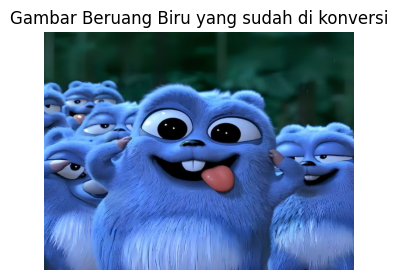

In [37]:
# Baca gambar dari file
#cv2.imread() mengembalikan array NumPy!
img_bgr = cv2.imread('haawooo.jpg')

# Resize agar tidak terlalu besar
img_bgr = cv2.resize(img_bgr, (650, 500))

# Cek tipe data: ternyata sudah array NumPy!
print("Tipe data:", type(img_bgr))     #numpy.ndarray
print("Shape    :", img_bgr.shape)     #(450, 300, 3)
print("Dtype    :", img_bgr.dtype)     # uint8

print()
print("Artinya:")
print(f" Tinggi   = {img_bgr.shape[0]} piksel")
print(f" Lebar    = {img_bgr.shape[1]} piksel")
print(f" Channel  = {img_bgr.shape[2]} (BGR)")

# Konversi BGR RGB untuk ditampilkan di Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Total piksel: ", img_bgr.shape[0] * img_bgr.shape[1])

#Tampilkan gambar
plt.figure(figsize=(4, 6))
plt.imshow(img_rgb)
plt.title('Gambar Beruang Biru yang sudah di konversi')
plt.axis('off')
plt.show()

=== MATRIKS f(x,y) Area 8x8 Piksel ===
Setiap angka nilai intensitas 1 piksel (0=hitam, 255=putih)

[[194 185 186 172 124 117 151 169]
 [192 189 190 192 171 128 132 163]
 [192 193 189 187 184 163 160 168]
 [192 185 185 189 186 182 176 172]
 [181 189 190 186 185 182 176 174]
 [178 186 188 183 186 184 178 175]
 [182 174 176 186 182 182 178 171]
 [141 177 181 174 178 175 171 169]] 

Contoh baca: f(180, 200) = 194
Contoh baca: f(181, 201) = 189

Resolusi (Tinggi x Lebar): (500, 650)
Total pixel   : 325000
Total size KB : 317.38 KB
Total size MB : 0.31 MB


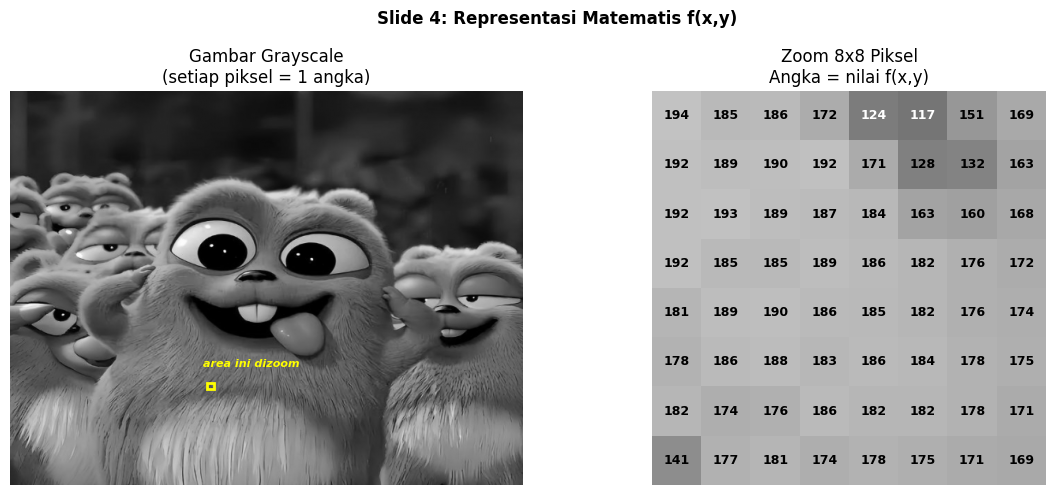

In [38]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Ambil area kecil 8x8 piksel dari tengah gambar (area perut)
area_kecil = img_gray[200:208, 180:188]

print("=== MATRIKS f(x,y) Area 8x8 Piksel ===")
print("Setiap angka nilai intensitas 1 piksel (0=hitam, 255=putih)\n")
print(area_kecil, "\n")

print("Contoh baca:", f"f(180, 200) = {img_gray[200, 180]}")
print("Contoh baca:", f"f(181, 201) = {img_gray[201, 181]}\n")

# Menghitung total jumlah piksel pada gambar (Tinggi x Lebar)
total_pixel = img_gray.shape[0] * img_gray.shape[1]

# Menghitung ukuran KiloByte (KB) dan menghitung ukuran MegaByte (MB)
konversi_kb = total_pixel / 1024
konversi_mb = konversi_kb / 1024

print("Resolusi (Tinggi x Lebar):", img_gray.shape)
print("Total pixel   :", total_pixel)
print("Total size KB :", f"{konversi_kb:.2f} KB")
print("Total size MB :", f"{konversi_mb:.2f} MB")

# Tampilkan area kecil dengan nilai angkanya
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Kiri: gambar grayscale penuh
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Gambar Grayscale\n(setiap piksel = 1 angka)')
axes[0].axis('off')

# tandai area yang kita zoom
import matplotlib.patches as patches
rect = patches.Rectangle((250,370), 8, 8, linewidth=2, edgecolor='yellow', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(245, 350, 'area ini dizoom', color='yellow', fontsize=8, fontweight='bold', fontstyle='italic')

# kanan: tampilkan nilai angka pada setiap piksel
axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        nilai = area_kecil[i, j]
        warna_teks = 'white' if nilai < 128 else 'black'
        axes[1].text(j, i, str(nilai), ha='center', va='center', fontsize=9, color=warna_teks, fontweight='bold')
axes[1].set_title('Zoom 8x8 Piksel\nAngka = nilai f(x,y)')
axes[1].axis('off')

plt.suptitle('Slide 4: Representasi Matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

=== MATRIKS f(x,y) Area 8x8 Piksel ===
Setiap pixel berisi nilai (R, G, B)

[[[165 198 252]
  [155 189 245]
  [156 189 246]
  [142 175 233]
  [ 92 127 190]
  [ 81 121 188]
  [110 157 228]
  [121 177 250]]

 [[161 196 250]
  [157 194 251]
  [159 194 254]
  [159 196 255]
  [137 175 237]
  [ 91 133 200]
  [ 89 139 209]
  [113 172 245]]

 [[158 198 252]
  [159 199 255]
  [155 194 254]
  [153 192 253]
  [149 189 249]
  [124 169 235]
  [116 168 237]
  [118 177 250]]

 [[156 199 254]
  [147 192 249]
  [147 191 252]
  [153 195 255]
  [149 191 254]
  [141 189 254]
  [130 185 253]
  [121 182 254]]

 [[142 188 246]
  [149 197 253]
  [151 198 255]
  [146 193 253]
  [146 192 252]
  [140 190 253]
  [129 185 251]
  [123 185 254]]

 [[137 186 246]
  [144 194 253]
  [146 196 254]
  [142 191 252]
  [146 193 252]
  [141 192 253]
  [130 188 251]
  [124 186 254]]

 [[140 189 254]
  [133 181 248]
  [135 183 250]
  [144 194 254]
  [140 190 253]
  [137 191 254]
  [130 188 252]
  [119 182 247]]

 [[ 99 146 224

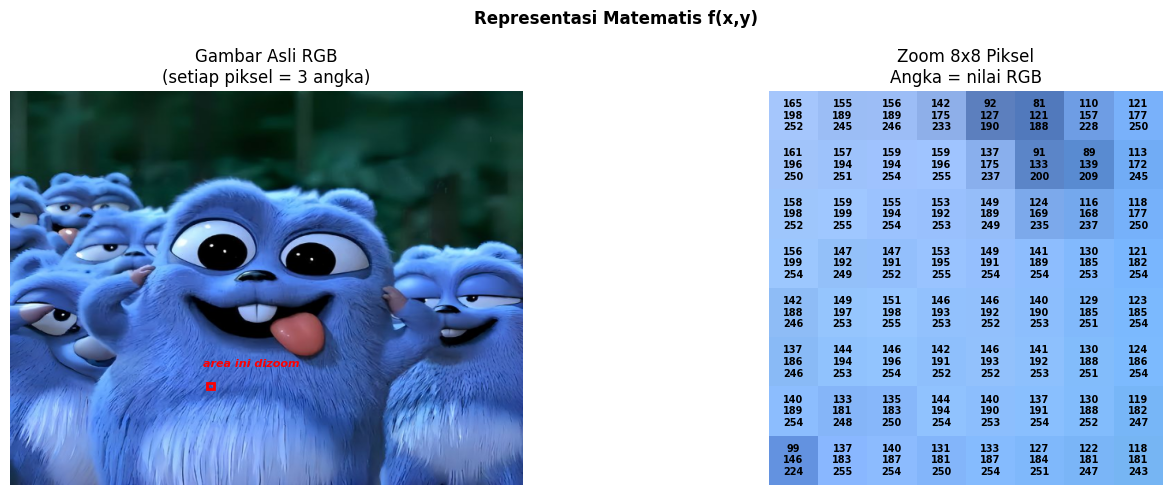

In [41]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Ambil area kecil 8x8 piksel dari tengah gambar (area perut)
area_kecil = img_rgb[200:208, 180:188]

print("=== MATRIKS f(x,y) Area 8x8 Piksel ===")
print("Setiap pixel berisi nilai (R, G, B)\n")
print(area_kecil, "\n")

# Menghitung total jumlah piksel pada gambar (Tinggi x Lebar)
total_pixel = img_rgb.shape[0] * img_rgb.shape[1]

# 2. Menghitung ukuran KiloByte (KB) dan menghitung ukuran MegaByte (MB)
konversi_kb = (total_pixel * 3) / 1024
konversi_mb = konversi_kb / 1024

print("Resolusi (Tinggi x Lebar x Channel):", img_rgb.shape)
print("Total pixel   :", total_pixel)
print("Total size KB :", f"{konversi_kb:.2f} KB")
print("Total size MB :", f"{konversi_mb:.2f} MB\n")

# Tampilkan area kecil dengan nilai angkanya
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Kiri: gambar RGB penuh
axes[0].imshow(img_rgb)
axes[0].set_title('Gambar Asli RGB\n(setiap piksel = 3 angka)')
axes[0].axis('off')

# tandai area yang kita zoom
import matplotlib.patches as patches
rect = patches.Rectangle((250,370), 8, 8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(245, 350, 'area ini dizoom', color='red', fontsize=8, fontweight='bold', fontstyle='italic')

# kanan: tampilkan nilai angka pada setiap piksel
axes[1].imshow(area_kecil)
for i in range(8):
    for j in range(8):
        r, g, b = area_kecil[i,j]
        text = f"{r}\n{g}\n{b}"
        axes[1].text(j, i, text, ha='center', va='center', fontsize=7, color='black', fontweight='bold')
axes[1].set_title('Zoom 8x8 Piksel\nAngka = nilai RGB')
axes[1].axis('off')

plt.suptitle('Representasi Matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()